In [1]:
import numpy as np

input_data = np.load('initial_data/function_2/initial_inputs.npy')
print(input_data.shape)
print(input_data)


(10, 2)
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]


In [2]:
output_data = np.load('initial_data/function_2/initial_outputs.npy')
print(output_data.shape)
print(output_data)


(10,)
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]


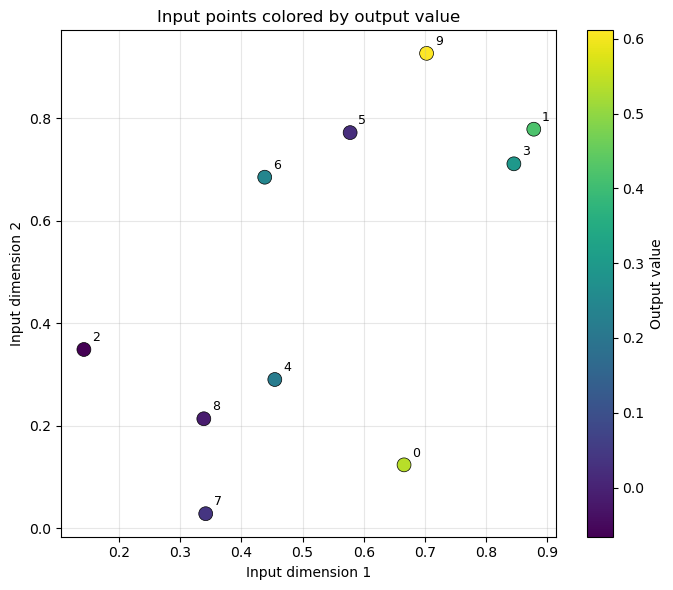

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
scatter = plt.scatter(input_data[:, 0], input_data[:, 1], 
                      c=output_data, cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='Output value')

# Annotate each point with its index
for i, (x, y) in enumerate(input_data):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('Input dimension 1')
plt.ylabel('Input dimension 2')
plt.title('Input points colored by output value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

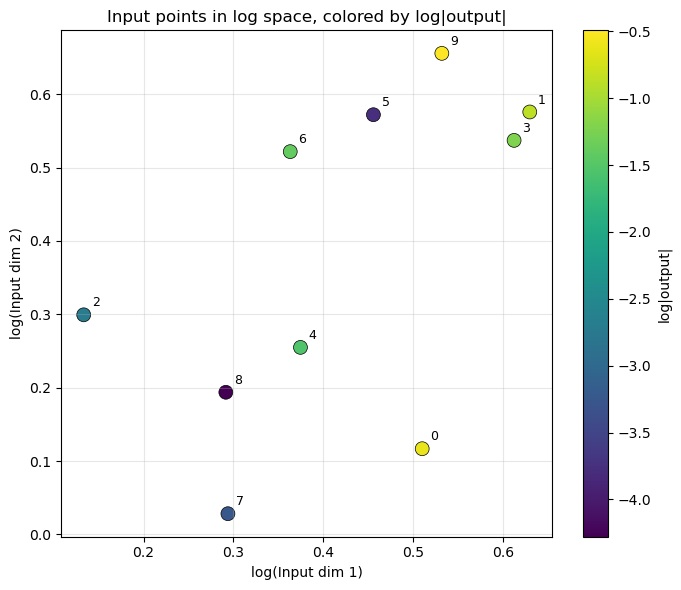

In [4]:
log_inputs = np.log1p(input_data)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(log_inputs[:, 0], log_inputs[:, 1], 
                      c=np.log(np.abs(output_data)), cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='log|output|')

for i, (x, y) in enumerate(log_inputs):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('log(Input dim 1)')
plt.ylabel('log(Input dim 2)')
plt.title('Input points in log space, colored by log|output|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern


In [6]:
kernel = C(1.0) * Matern(length_scale=1.0, nu=2.5)

In [7]:
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(input_data, output_data)


GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=10, normalize_y=True)

In [8]:
from scipy.stats import norm

def expected_improvement(X_candidates, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    Z = (mu - y_best - xi) / (sigma + 1e-9)
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Generate candidate points and find best
candidates = np.random.rand(1000, 2)
ei_scores = expected_improvement(candidates, gp, y_best=output_data.max())
best_next = candidates[np.argmax(ei_scores)]
print(f"Suggested next input: {best_next}")

Suggested next input: [0.75904807 0.96537508]


In [10]:
mean, std = gp.predict([best_next], return_std=True)

print(f"Predicted mean: {mean[0]:.6e}")
print(f"Uncertainty (std): {std[0]:.6e}")

Predicted mean: 5.928535e-01
Uncertainty (std): 1.303603e-01
